# PLACEMENT-PROJECT
(Logistic-regression)

In [28]:
import pandas as pd
import numpy as np



In [29]:
df = pd.read_csv("placement.csv")
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [30]:
df.info

<bound method DataFrame.info of     Unnamed: 0  cgpa     iq  placement
0            0   6.8  123.0          1
1            1   5.9  106.0          0
2            2   5.3  121.0          0
3            3   7.4  132.0          1
4            4   5.8  142.0          0
..         ...   ...    ...        ...
95          95   4.3  200.0          0
96          96   4.4   42.0          0
97          97   6.7  182.0          1
98          98   6.3  103.0          1
99          99   6.2  113.0          1

[100 rows x 4 columns]>

In [31]:
df.shape

(100, 4)

## Steps

### 0. Preprocessing + EDA + Feature Selection
### 1. Extract input and output cols
### 2. Scale the values
### 3. Train/Test split
### 4. Train Model
### 5. Evaluate the model/ Model selection
### 6. Deploy the model

In [32]:
df = df.iloc[:,1:]
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


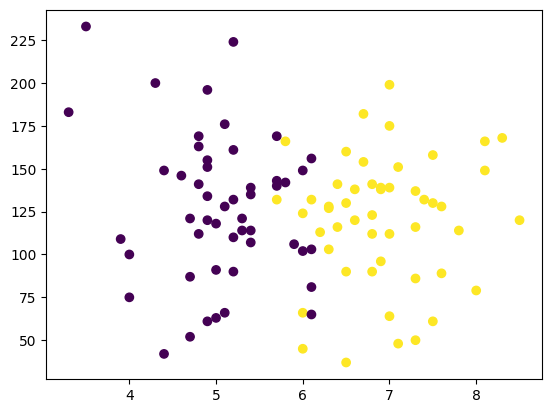

In [33]:
import matplotlib.pyplot as plt
plt.scatter(df['cgpa'],df['iq'], c=df['placement'])

In [34]:
x = df.iloc[:,0:2]
y = df.iloc[:,-1]


In [35]:

x.shape


(100, 2)

In [36]:
y.shape

(100,)

In [37]:
from sklearn.model_selection import train_test_split

X_train,X_test, Y_train, Y_test = train_test_split(x,y,test_size=0.1)

In [38]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


In [39]:
X_train = scaler.fit_transform(X_train)

In [41]:
X_train

array([[-0.06497385, -0.54219733],
       [-0.78468423,  2.64993492],
       [ 1.3744469 ,  0.13809315],
       [ 1.73430208, -1.14399275],
       [-0.06497385,  0.68755854],
       [-0.15493765, -0.43753725],
       [ 1.1945193 ,  0.24275323],
       [-0.78468423,  1.00153876],
       [ 1.82426588,  0.68755854],
       [-0.96461182, -0.12355703],
       [-0.87464802, -1.48413799],
       [ 0.65473652, -0.85617755],
       [ 0.56477272,  0.81838363],
       [ 1.3744469 , -0.88234257],
       [ 0.11495374, -0.25438212],
       [-0.69472043, -0.22821711],
       [ 1.10455551, -0.96083762],
       [-1.32446701,  0.60906349],
       [-1.05457562,  1.91731441],
       [-1.86424979, -1.24865283],
       [ 0.20491754,  0.11192813],
       [-1.5043946 , -2.11209843],
       [ 1.2844831 , -1.61496308],
       [ 0.38484513,  0.19042319],
       [-0.60475663,  0.32124828],
       [ 0.47480893,  0.39974334],
       [-0.96461182, -0.83001253],
       [ 0.74470032,  0.39974334],
       [ 0.92462791,

In [42]:
X_test = scaler.transform(X_test)

In [43]:
X_test

array([[-2.31406877,  2.88542009],
       [-0.87464802,  1.39401404],
       [ 0.20491754, -0.51603231],
       [-2.49399637,  1.57716917],
       [ 0.02498994, -0.51603231],
       [-0.06497385, -1.48413799],
       [-0.24490145,  0.50440341],
       [ 0.65473652,  0.00726806],
       [-1.23450321, -0.04506198],
       [-0.96461182, -1.56263305]])

In [44]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()

In [45]:
#train model
clf.fit(X_train,Y_train)

LogisticRegression()

In [48]:
Y_pred = clf.predict(X_test)

In [49]:
Y_test

,placement
50,0
15,0
98,1
17,0
14,0
45,1
4,0
0,1
24,0
7,0


In [51]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_test,Y_pred)

0.9

<Axes: >

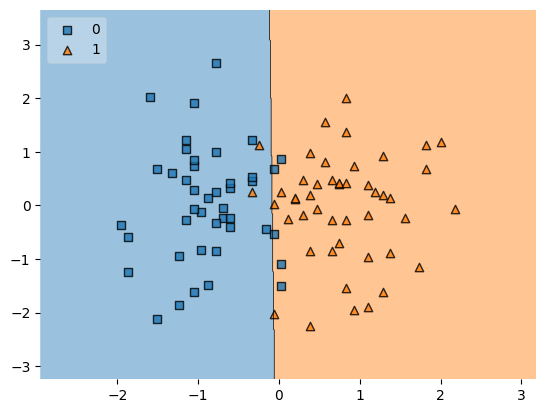

In [55]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X_train,Y_train.values,clf=clf, legend=2)

In [56]:
import pickle
pickle.dump(clf,open('model.pkl','wb'))